# Probabilistic Reasoning Hackathon

This notebook is not the final product, I'm using it to verify the `Stage 1` document data and to build the two figures: the DPOC-by-race chart and the Bayes network structure diagram.

`voter_access.ipynb` is the final deliverable, Mai owns the model in it. Every written here will get handed over during pairing, so what you see below are the inputs to that notebook, not the model itself.

## 1. Orientation

In [1]:
try:
    from pgmpy.models import DiscreteBayesianNetwork
    from pgmpy.factors.discrete import TabularCPD
    from pgmpy.inference import VariableElimination
    from pgmpy.sampling import BayesianModelSampling
except ImportError as exc:
    raise ImportError("pgmpy is required. Run !pip install pgmpy.") from exc

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd

/Users/mailimcghee/Desktop/Code/AI/Hackathon02/Voter-access-bayesian-network/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/mailimcghee/Desktop/Code/AI/Hackathon02/Voter-access-bayesian-network/venv/lib/python3.14/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


## 2. Stage 1 data

In [2]:
stage1_documents = pd.read_csv("data/stage1_documents.csv")

verified_count = (stage1_documents["verified_by_ty"] == "yes").sum()
total_rows = len(stage1_documents)

print(f"Stage 1 rows: {total_rows}")
print(f"Verified against the primary source: {verified_count} of {total_rows}")
print()
print("Confidence tier:")
print(stage1_documents["confidence_tier"].value_counts().to_string())

# Check that any unverified row won't reach a figure
assert verified_count == total_rows

display_columns = ["verified_by_ty", "measure", "subgroup", "percentage", "population_count", "denominator", "source_key", "confidence_tier"]
display(stage1_documents[display_columns])

Stage 1 rows: 14
Verified against the primary source: 14 of 14

Confidence tier:
confidence_tier
published                11
derived                   1
not_measured_for_dpoc     1
not_available             1


,verified_by_ty,measure,subgroup,percentage,population_count,denominator,source_key,confidence_tier
0,yes,lacks_easy_dpoc_access,national,9.1,21300000.0,all_voting_age_citizens,cdce_voterid_2024,published
1,yes,lacks_dpoc_entirely,national,1.6,3800000.0,all_voting_age_citizens,cdce_voterid_2024,derived
2,yes,lacks_easy_dpoc_access,citizens_of_color,11.0,8400000.0,all_voting_age_citizens,cdce_voterid_2024,published
3,yes,lacks_easy_dpoc_access,white_citizens,8.0,12900000.0,all_voting_age_citizens,cdce_voterid_2024,published
4,yes,lacks_dpoc_entirely,citizens_of_color,3.0,NaN,all_voting_age_citizens,cdce_voterid_2024,published
5,yes,lacks_dpoc_entirely,white_citizens,1.0,NaN,all_voting_age_citizens,cdce_voterid_2024,published
6,yes,lacks_easy_dpoc_access,independents,13.0,4500000.0,all_voting_age_citizens,cdce_voterid_2024,published
7,yes,lacks_easy_dpoc_access,democrats,10.0,9700000.0,all_voting_age_citizens,cdce_voterid_2024,published
8,yes,lacks_easy_dpoc_access,republicans,7.0,7100000.0,all_voting_age_citizens,cdce_voterid_2024,published
9,yes,lacks_easy_dpoc_access,male,11.0,12000000.0,all_voting_age_citizens,cdce_2025,published


## A few notes about the table above

Every national figure that you see comes from a **single survey**: n = 2,386 U.S. citizens, fielded September 12 to October 4, 2023 by SSRS, funded by CDCE, VoteRiders, Public Wise, and the Brennan Center. The Brennan Center article, the CDCE feature, and the CDCE Voter ID report are three publications of that survey, not three independent studies

All percentages are over `all voting-age U.S. citizens`, whether or not they are registered. The same source also reports DPOC figures over **registered voters only** (6% cannot readily access, 1% have none at all), 

## 3. Figure: DPOC Access by Race

measure            lacks_dpoc_entirely  lacks_easy_dpoc_access  has_but_cannot_access
subgroup                                                                             
white_citizens                     1.0                     8.0                    7.0
citizens_of_color                  3.0                    11.0                    8.0


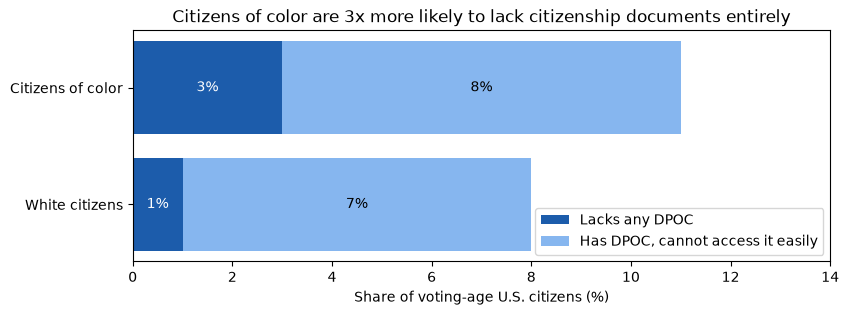

In [3]:
# Reshaping the two race subgroups so that each row is one subgroup and each measure a column
race_rows = stage1_documents[stage1_documents["subgroup"].isin(["citizens_of_color", "white_citizens"])]
race_rows_ready = len(race_rows) == 4

# "Cannot readily access" already includes "lacks entirely", so the segment
# that's lighter is derived by subtraction rather than typed in
by_race = race_rows.pivot(index="subgroup", columns="measure", values="percentage")
by_race["has_but_cannot_access"] = (by_race["lacks_easy_dpoc_access"] - by_race["lacks_dpoc_entirely"])
by_race = by_race.loc[["white_citizens", "citizens_of_color"]]

palette = ["#1C5CAB", "#86B6EF"]
display_labels = ["White citizens", "Citizens of color"]

if race_rows_ready:
    print(by_race.to_string())

    plt.figure(figsize=(9, 3))
    severe_bars = plt.barh(
        display_labels,
        by_race["lacks_dpoc_entirely"],
        color=palette[0],
        label="Lacks any DPOC",
    )
    access_bars = plt.barh(
        display_labels,
        by_race["has_but_cannot_access"],
        left=by_race["lacks_dpoc_entirely"],
        color=palette[1],
        label="Has DPOC, cannot access it easily",
    )

    plt.bar_label(severe_bars, fmt="%.0f%%", label_type="center", color="white")
    plt.bar_label(access_bars, fmt="%.0f%%", label_type="center")

    plt.xlim(0, 14)
    plt.xlabel("Share of voting-age U.S. citizens (%)")
    plt.title("Citizens of color are 3x more likely to lack citizenship documents entirely")
    plt.legend(loc="lower right")
    plt.savefig("figures/dpoc_by_race.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("Chart skipped: expected 2 race subgroups x 2 measures in stage1_documents.")

## 4. Structure

Construct the directed edges and draw them with fixed NetworkX positions.

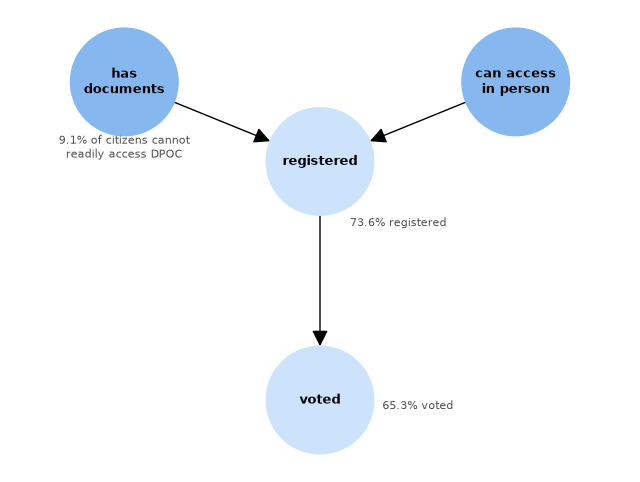

In [4]:
voter_edges = [
    ("has_documents", "registered"),
    ("can_access_in_person", "registered"),
    ("registered", "voted"),
]
voter_model = DiscreteBayesianNetwork(voter_edges)

voter_structure_ready = (
    len(voter_model.nodes()) == 4 and len(voter_model.edges()) == 3
)

positions = {
    "has_documents": (-2.0, 1.0),
    "can_access_in_person":(2.0, 1.0),
    "registered": (0.0, 0.0),
    "voted": (0.0, -3),
}
node_labels = {
    "has_documents": "has\ndocuments",
    "can_access_in_person": "can access\nin person",
    "registered": "registered",
    "voted": "voted",
}

barrier_nodes = ["has_documents", "can_access_in_person"]
node_palette = [
    "#86B8EF" if node in barrier_nodes 
    else "#CDE2FB" for node in voter_model.nodes()
]

node_annotations = [
    (-2.0, 0.35, "9.1% of citizens cannot\nreadily access DPOC"),
    (2.0, 0.35, ""),
    (0.8, -0.7, "73.6% registered"),
    (1, -3, "65.3% voted"),
]

if voter_structure_ready:
    plt.figure(figsize=(8, 6))
    nx.draw_networkx(
        voter_model,
        pos=positions,
        labels=node_labels,
        node_color=node_palette,
        node_size=6000,
        arrowsize=24,
        font_size=9,
        font_weight="bold",
    )

    for annotation_x, annotation_y, annotation_text in node_annotations:
        plt.text(
            annotation_x,
            annotation_y,
            annotation_text,
            ha="center",
            va="top",
            fontsize=8,
            color="#52514E",
        )
        
    plt.margins(x=0.22, y=0.16)
    plt.axis("off")
    plt.savefig("figures/bayes_network_structure.png", dpi=200, bbox_inches="tight")
    plt.show()
else:
    print("Structure incomplete: expected 4 nodes and 3 edges.")